# 2025-06-16 - Beta diversity

## Summary

This notebook is part of the 1st July sprint to get a draft. Here I'll study the beta-diversity among our Motus-g1 data, including:

- Differential composition among habitats.
- Correlation with environmental traits such as antropic intervention.
- Correlation with distance between sites. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from skbio.tree import TreeNode
from skbio.diversity import beta_diversity
from skbio.stats.distance import permanova, anosim
from skbio.stats.ordination import pcoa
import geopy.distance
import matplotlib.pyplot as plt
from rdflib import Graph
plt.rcParams['svg.fonttype'] = 'none'
habitat_palette = {
    "Crop": "#0CAB7B", 
    "Edge": "#3A8DFA", 
    "Oak": "#FB2231",
    "Wasteland": "#FFC51F"
}

In [134]:
# motus_df = pd.read_csv("../results/2025-06-13.sprint/base.motus-hits.csv", sep=';')
# motus_df

In [5]:
data = Graph()
data.parse(open("data/miripvir.2025-07-09.ttl"))

res = data.query(
"""
PREFIX mvrtaxon: <http://localhost:8000/taxon/>
PREFIX mvrlib: <http://localhost:8000/library/>
PREFIX mvront: <http://localhost:8000/ont/>
PREFIX mvrcol: <http://localhost:8000/collection/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#> 
PREFIX emi: <https://purl.org/emi#>
PREFIX uniprotrdfs: <http://purl.uniprot.org/core/>

SELECT  ?taxid ?scientific_name ?gtdb_genome_representative ?site ?habitat (COUNT(?lib) AS ?number_hits)
WHERE {
    ?lib mvront:Reported ?hit .
    ?hit mvront:BelongsTo mvrcol:0000 .
    ?hit uniprotrdfs:Taxon ?taxon .
    ?taxon mvront:is_pab "true" .
    ?taxon dwc:taxonID ?taxid .
    ?taxon dwc:scientificName ?scientific_name .
    ?taxon mvront:GTDBGenomeReference ?gtdb_genome_representative .
    ?lib mvront:Sampled_from ?s .
    ?s rdfs:label ?site .
    ?s wlo:habitat ?habitat .
} GROUP BY ?scientific_name ?site

"""
)
detections = pd.DataFrame(res, columns=list(map(str, res.vars)))
detections['number_hits'] = detections['number_hits'].astype(int) 
detections['scientific_name'] = detections['scientific_name'].apply(lambda x: str(x))
detections['gtdb_genome_representative'] = detections['gtdb_genome_representative'].apply(lambda x: str(x))
detections['site'] = detections['site'].apply(lambda x: str(x))
detections['habitat'] = detections['habitat'].apply(lambda x: str(x))
detections

,taxid,scientific_name,gtdb_genome_representative,site,habitat,number_hits
0,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,M1,Crop,3
1,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,Q1,Oak,2
2,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,M2,Crop,2
3,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,M3,Crop,1
4,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,M4,Crop,1
...,...,...,...,...,...,...
294,1933817,Kribbella sp. ALI-6-A,RS GCF 001984195.1,Z2,Crop,1
295,1566262,Rhizobium sp. NFR07,RS GCF 900111905.1,Z2,Crop,1
296,1770058,Devosia elaeis,RS GCF 001650025.1,Z2,Crop,1
297,1735683,Sphingomonas sp. Leaf17,RS GCF 001421505.1,C1,Crop,1


In [6]:
detections.drop_duplicates(['scientific_name', 'site'])

,taxid,scientific_name,gtdb_genome_representative,site,habitat,number_hits
0,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,M1,Crop,3
1,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,Q1,Oak,2
2,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,M2,Crop,2
3,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,M3,Crop,1
4,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,M4,Crop,1
...,...,...,...,...,...,...
294,1933817,Kribbella sp. ALI-6-A,RS GCF 001984195.1,Z2,Crop,1
295,1566262,Rhizobium sp. NFR07,RS GCF 900111905.1,Z2,Crop,1
296,1770058,Devosia elaeis,RS GCF 001650025.1,Z2,Crop,1
297,1735683,Sphingomonas sp. Leaf17,RS GCF 001421505.1,C1,Crop,1


In [9]:
# tree = TreeNode.read("../data/taxonomy/bac120.tree")
tree = TreeNode.read("data/bac120.tree")

## Direct calculations

In [5]:
# counts_byspecies = motus_df.value_counts(
#     ['Site_code', 'Habitat', 'species', 'library']
# ).reset_index().value_counts(
#     ['Site_code', 'Habitat', 'species']
# ).reset_index()

In [6]:
# counts_byspecies_pvt = counts_byspecies.pivot(index=['Site_code', 'Habitat'], columns='species', values='count').fillna(0)

In [7]:
# counts_byspecies_data = counts_byspecies_pvt.values
# counts_byspecies_index = counts_byspecies_pvt.index.to_frame()['Site_code'].values

In [10]:
detections_pvt = detections.pivot(index=['site', 'habitat'], columns=['scientific_name'], values='number_hits').fillna(0)
counts_byspecies_data = detections_pvt.values
counts_byspecies_index = detections_pvt.index.to_frame()['site'].values

### Bray Curtis

In [11]:
counts_byspecies_bc_dm = beta_diversity('braycurtis', counts_byspecies_data, counts_byspecies_index)

<Axes: >

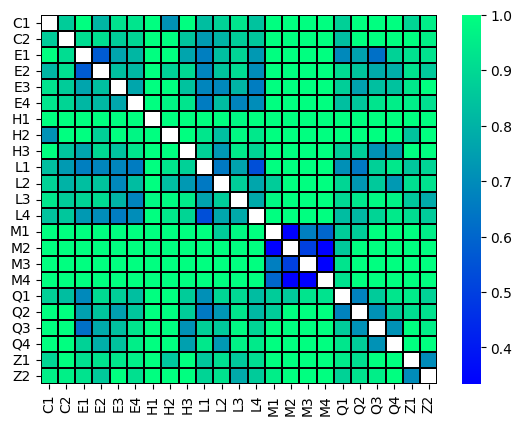

In [12]:
sns.heatmap(counts_byspecies_bc_dm.to_data_frame(), cmap='winter', mask=np.eye(23), linewidth=0.01, linecolor='black')

/home/bcz/miniconda3/envs/miripvir25/lib/python3.9/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:214: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.025146361576930745 whereas the largest positive one is 1.8667360898713277.
  warn(


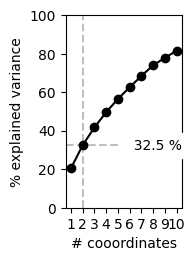

In [13]:
pc = pcoa(counts_byspecies_bc_dm, number_of_dimensions=10)
fig, ax = plt.subplots(1)
fig.set_size_inches(1.5,2.5)
ax.plot(np.arange(1, 11), 100 * pc.proportion_explained.values.cumsum(), marker='o', color='black')
ax.set_ylim([0, 100])
ax.set_xticks(np.arange(1, 11))
ax.set_ylabel(r"% explained variance")
ax.set_xlabel(r"# cooordinates")
ax.axvline(2.0, color='black', linestyle='--', alpha=0.25)
ax.axhline(100 * pc.proportion_explained.values.cumsum()[1], color='black', linestyle='--', alpha=0.25)
ax.text(
    8.0, 100 * pc.proportion_explained.values.cumsum()[1], 
    "{0:6.1f} %".format(100 * pc.proportion_explained.values.cumsum()[1]) ,
    horizontalalignment='center', verticalalignment='center', bbox=dict(facecolor='white', alpha=1.0, edgecolor='white')
)
fig.savefig("figures/fig03.pcoa-variance.svg")

In [14]:
pcsamples = pd.merge(
    pc.samples.copy().reset_index().rename(columns={'index': 'site'}), 
    detections[['site', 'habitat']].drop_duplicates(keep='first'),
    on='site'
)

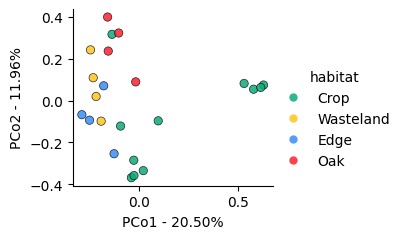

In [15]:
g = sns.relplot(data=pcsamples[['PC1', 'PC2', 'habitat']], x="PC1", y="PC2", hue='habitat', height=2.5, aspect=1.25, palette=habitat_palette, edgecolor='black', alpha=0.85)
g.set_xlabels("PCo1 - {0:5.2f}%".format(pc.proportion_explained.tolist()[0] * 100))
g.set_ylabels("PCo2 - {0:5.2f}%".format(pc.proportion_explained.tolist()[1] * 100))
g.savefig("figures/fig03.pcoa.svg")

In [16]:
habitats = pcsamples['habitat'].values
permanova(counts_byspecies_bc_dm, habitats, permutations=10000)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      23
number of groups                  4
test statistic             1.853372
p-value                       0.002
number of permutations        10000
Name: PERMANOVA results, dtype: object

In [17]:
anosim(counts_byspecies_bc_dm, habitats, permutations=10000)

method name                 ANOSIM
test statistic name              R
sample size                     23
number of groups                 4
test statistic           -0.045434
p-value                   0.651635
number of permutations       10000
Name: ANOSIM results, dtype: object

### Jaccard

In [18]:
counts_byspecies_jc_dm = beta_diversity('jaccard', counts_byspecies_data, counts_byspecies_index)

Text(8.0, 27.75592410055035, '  27.8 %')

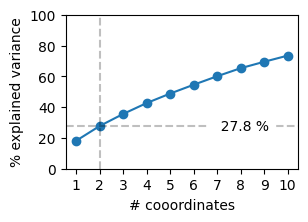

In [19]:
pc = pcoa(counts_byspecies_jc_dm, number_of_dimensions=10)
fig, ax = plt.subplots(1)
fig.set_size_inches(3,2)
ax.plot(np.arange(1, 11), 100 * pc.proportion_explained.values.cumsum(), marker='o')
ax.set_ylim([0, 100])
ax.set_xticks(np.arange(1, 11))
ax.set_ylabel(r"% explained variance")
ax.set_xlabel(r"# cooordinates")
ax.axvline(2.0, color='black', linestyle='--', alpha=0.25)
ax.axhline(100 * pc.proportion_explained.values.cumsum()[1], color='black', linestyle='--', alpha=0.25)
ax.text(
    8.0, 100 * pc.proportion_explained.values.cumsum()[1], 
    "{0:6.1f} %".format(100 * pc.proportion_explained.values.cumsum()[1]) ,
    horizontalalignment='center', verticalalignment='center', bbox=dict(facecolor='white', alpha=1.0, edgecolor='white')
)

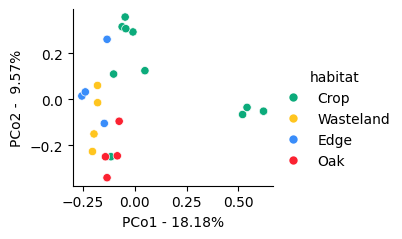

In [20]:
pcsamples = pd.merge(
    pc.samples.copy().reset_index().rename(columns={'index': 'site'}), 
    detections[['site', 'habitat']].drop_duplicates(keep='first'),
    on='site'
)
g = sns.relplot(data=pcsamples[['PC1', 'PC2', 'habitat']], x="PC1", y="PC2", hue='habitat', height=2.5, aspect=1.25, palette=habitat_palette)
g.set_xlabels("PCo1 - {0:5.2f}%".format(pc.proportion_explained.tolist()[0] * 100))
g.set_ylabels("PCo2 - {0:5.2f}%".format(pc.proportion_explained.tolist()[1] * 100))

In [21]:
habitats = pcsamples['habitat'].values
permanova(counts_byspecies_jc_dm, habitats, permutations=10000)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      23
number of groups                  4
test statistic             1.629376
p-value                      0.0041
number of permutations        10000
Name: PERMANOVA results, dtype: object

In [22]:
anosim(counts_byspecies_bc_dm, habitats, permutations=10000)

method name                 ANOSIM
test statistic name              R
sample size                     23
number of groups                 4
test statistic           -0.045434
p-value                   0.653135
number of permutations       10000
Name: ANOSIM results, dtype: object

### UniFrac

In [23]:
detections

,taxid,scientific_name,gtdb_genome_representative,site,habitat,number_hits
0,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,M1,Crop,3
1,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,Q1,Oak,2
2,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,M2,Crop,2
3,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,M3,Crop,1
4,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,M4,Crop,1
...,...,...,...,...,...,...
294,1933817,Kribbella sp. ALI-6-A,RS GCF 001984195.1,Z2,Crop,1
295,1566262,Rhizobium sp. NFR07,RS GCF 900111905.1,Z2,Crop,1
296,1770058,Devosia elaeis,RS GCF 001650025.1,Z2,Crop,1
297,1735683,Sphingomonas sp. Leaf17,RS GCF 001421505.1,C1,Crop,1


In [24]:
detections.value_counts(['site', 'habitat', 'gtdb_genome_representative']).reset_index()

,site,habitat,gtdb_genome_representative,count
0,C1,Crop,RS GCF 000023205.1,1
1,L4,Edge,RS GCF 001424105.1,1
2,L4,Edge,RS GCF 001423085.1,1
3,L4,Edge,RS GCF 001422665.1,1
4,L4,Edge,RS GCF 001422375.1,1
...,...,...,...,...
294,E4,Wasteland,RS GCF 900111275.1,1
295,E4,Wasteland,RS GCF 900110945.1,1
296,E4,Wasteland,RS GCF 900110275.1,1
297,E4,Wasteland,RS GCF 900101265.1,1


In [25]:
detections.query('gtdb_genome_representative == "RS GCF 028621715.1"').query('site == "L3"')

,taxid,scientific_name,gtdb_genome_representative,site,habitat,number_hits
236,316,Stutzerimonas stutzeri,RS GCF 028621715.1,L3,Edge,1


In [26]:
#  = motus_df.dropna(subset=['gtdb_genome_representative']).value_counts(
#     ['Site_code', 'Habitat', 'gtdb_genome_representative']
# ).reset_index().value_counts(
#     ['Site_code', 'Habitat']
# ).reset_index().rename(columns={'count': 'hits'})

# counts_bygtdbrep = motus_df.dropna(subset=['gtdb_genome_representative']).value_counts(
#     ['Site_code', 'Habitat', 'gtdb_genome_representative', 'library']
# ).reset_index().value_counts(
#     ['Site_code', 'Habitat', 'gtdb_genome_representative']
# ).reset_index().rename(columns={'count': 'hits'})
# # counts_bygtdbrep

# counts_bygtdbrep_pvt = counts_bygtdbrep.pivot(index=['Site_code', 'Habitat'], columns='gtdb_genome_representative', values='hits').fillna(0)
# counts_bygtdbrep_pvt
detections_groupby_gtdbrep = detections.groupby(['site', 'habitat', 'gtdb_genome_representative'], as_index=False)['number_hits'].sum()
detections_pvt = detections_groupby_gtdbrep.pivot(index=['site', 'habitat'], columns=['gtdb_genome_representative'], values='number_hits').fillna(0)
# counts_bygtdbrep_data = detections_pvt.values
# counts_byspecies_index = detections_pvt.index.to_frame()['site'].values
detections_pvt

,gtdb_genome_representative,GB GCA 003240625.1,GB GCA 013337045.2,GB GCA 014218215.1,GB GCA 016839165.1,GB GCA 022631215.1,GB GCA 900468285.1,RS GCF 000007145.1,RS GCF 000014445.1,RS GCF 000023205.1,RS GCF 000282095.2,...,RS GCF 900109645.1,RS GCF 900110275.1,RS GCF 900110945.1,RS GCF 900111275.1,RS GCF 900111905.1,RS GCF 900113115.1,RS GCF 900113485.1,RS GCF 900129505.1,RS GCF 900142655.1,RS GCF 900177325.1
site,habitat,,,,,,,,,,,,,,,,,,,,,
C1,Crop,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C2,Crop,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
E1,Wasteland,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
E2,Wasteland,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
E3,Wasteland,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
E4,Wasteland,2.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,...,0.0,2.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
H1,Crop,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H2,Crop,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H3,Crop,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [27]:
counts_bygtdbrep_data = detections_pvt.values
counts_bygtdbrep_index = detections_pvt.index.to_frame()['site'].values
counts_bygtdbrep_species = detections_pvt.columns

In [28]:

counts_bygtdbrep_uuf_dm = beta_diversity("unweighted_unifrac", counts_bygtdbrep_data[:, :], counts_bygtdbrep_index[:], tree=tree, taxa=counts_bygtdbrep_species)

Text(8.0, 45.77424640582286, '  45.8 %')

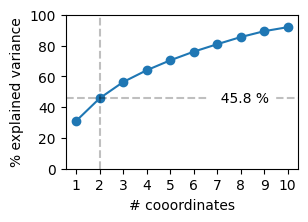

In [29]:
pc = pcoa(counts_bygtdbrep_uuf_dm, number_of_dimensions=10)
fig, ax = plt.subplots(1)
fig.set_size_inches(3,2)
ax.plot(np.arange(1, 11), 100 * pc.proportion_explained.values.cumsum(), marker='o')
ax.set_ylim([0, 100])
ax.set_xticks(np.arange(1, 11))
ax.set_ylabel(r"% explained variance")
ax.set_xlabel(r"# cooordinates")
ax.axvline(2.0, color='black', linestyle='--', alpha=0.25)
ax.axhline(100 * pc.proportion_explained.values.cumsum()[1], color='black', linestyle='--', alpha=0.25)
ax.text(
    8.0, 100 * pc.proportion_explained.values.cumsum()[1], 
    "{0:6.1f} %".format(100 * pc.proportion_explained.values.cumsum()[1]) ,
    horizontalalignment='center', verticalalignment='center', bbox=dict(facecolor='white', alpha=1.0, edgecolor='white')
)

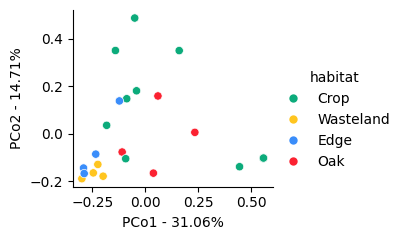

In [30]:
pcsamples = pd.merge(
    pc.samples.copy().reset_index().rename(columns={'index': 'site'}), 
    detections[['site', 'habitat']].drop_duplicates(keep='first'),
    on='site'
)
g = sns.relplot(data=pcsamples[['PC1', 'PC2', 'habitat']], x="PC1", y="PC2", hue='habitat', height=2.5, aspect=1.25, palette=habitat_palette)
g.set_xlabels("PCo1 - {0:5.2f}%".format(pc.proportion_explained.tolist()[0] * 100))
g.set_ylabels("PCo2 - {0:5.2f}%".format(pc.proportion_explained.tolist()[1] * 100))

In [31]:
habitats = pcsamples['habitat'].values
permanova(counts_bygtdbrep_uuf_dm, habitats, permutations=10000)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      23
number of groups                  4
test statistic             2.195312
p-value                      0.0037
number of permutations        10000
Name: PERMANOVA results, dtype: object

### Weigthed UniFrac

In [32]:
counts_bygtdbrep_wuf_dm = beta_diversity("weighted_unifrac", counts_bygtdbrep_data[:, :], counts_bygtdbrep_index[:], tree=tree, taxa=counts_bygtdbrep_species)

/home/bcz/miniconda3/envs/miripvir25/lib/python3.9/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:214: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.4758630311842076 whereas the largest positive one is 21.984476067601005.
  warn(


Text(8.0, 62.29255114518122, '  62.3 %')

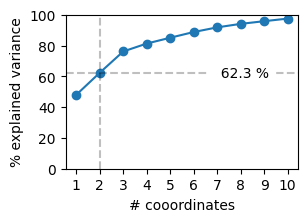

In [33]:
pc = pcoa(counts_bygtdbrep_wuf_dm, number_of_dimensions=10)
fig, ax = plt.subplots(1)
fig.set_size_inches(3,2)
ax.plot(np.arange(1, 11), 100 * pc.proportion_explained.values.cumsum(), marker='o')
ax.set_ylim([0, 100])
ax.set_xticks(np.arange(1, 11))
ax.set_ylabel(r"% explained variance")
ax.set_xlabel(r"# cooordinates")
ax.axvline(2.0, color='black', linestyle='--', alpha=0.25)
ax.axhline(100 * pc.proportion_explained.values.cumsum()[1], color='black', linestyle='--', alpha=0.25)
ax.text(
    8.0, 100 * pc.proportion_explained.values.cumsum()[1], 
    "{0:6.1f} %".format(100 * pc.proportion_explained.values.cumsum()[1]) ,
    horizontalalignment='center', verticalalignment='center', bbox=dict(facecolor='white', alpha=1.0, edgecolor='white')
)

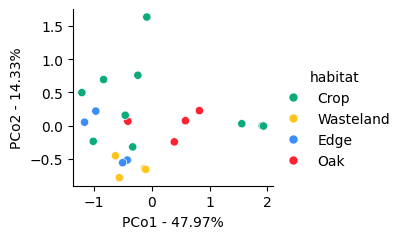

In [34]:
pcsamples = pd.merge(
    pc.samples.copy().reset_index().rename(columns={'index': 'site'}), 
    detections[['site', 'habitat']].drop_duplicates(keep='first'),
    on='site'
)
g = sns.relplot(data=pcsamples[['PC1', 'PC2', 'habitat']], x="PC1", y="PC2", hue='habitat', height=2.5, aspect=1.25, palette=habitat_palette)
g.set_xlabels("PCo1 - {0:5.2f}%".format(pc.proportion_explained.tolist()[0] * 100))
g.set_ylabels("PCo2 - {0:5.2f}%".format(pc.proportion_explained.tolist()[1] * 100))

In [35]:
habitats = pcsamples['habitat'].values
permanova(counts_bygtdbrep_wuf_dm, habitats, permutations=10000)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      23
number of groups                  4
test statistic             1.824372
p-value                    0.058694
number of permutations        10000
Name: PERMANOVA results, dtype: object

## Correlating with geographical distance

In [36]:
res = data.query(
"""
PREFIX mvrtaxon: <http://localhost:8000/taxon/>
PREFIX mvrlib: <http://localhost:8000/library/>
PREFIX mvront: <http://localhost:8000/ont/>
PREFIX mvrcol: <http://localhost:8000/collection/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#> 
PREFIX emi: <https://purl.org/emi#>
PREFIX uniprotrdfs: <http://purl.uniprot.org/core/>
PREFIX fao: <https://w3id.org/fao-ipgr/multi-passport-descriptor.owl#>

SELECT  ?site ?habitat ?latitude ?longitude ?town
WHERE {
    ?s rdfs:label ?site .
    ?s wlo:habitat ?habitat .
    ?s dwc:decimalLatitude ?latitude .
    ?s dwc:decimalLongitude ?longitude .
    ?s fao:0000122 ?town
} 

"""
)
geography = pd.DataFrame(res, columns=list(map(str, res.vars)))
geography['latitude'] = geography['latitude'].astype(float)
geography['longitude'] = geography['longitude'].astype(float)
geography['site'] = geography['site'].apply(lambda x: str(x))
geography['habitat'] = geography['habitat'].apply(lambda x: str(x))
geography['town'] = geography['town'].apply(lambda x: str(x))

# detections['number_hits'] = detections['number_hits'].astype(int) 
# detections['scientific_name'] = detections['scientific_name'].apply(lambda x: str(x))
# detections['gtdb_genome_representative'] = detections['gtdb_genome_representative'].apply(lambda x: str(x))

# detections['habitat'] = detections['habitat'].apply(lambda x: str(x))
# detections
geography

,site,habitat,latitude,longitude,town
0,C1,Crop,40.051302,-3.593308,Aranjuez
1,C2,Crop,40.043193,-3.599064,Aranjuez
2,H1,Crop,40.049330,-3.477574,Villaconejos
3,H2,Crop,40.085899,-3.214026,Villamanrique de Tajo
4,H3,Crop,40.245852,-3.253943,Tielmes
5,M1,Crop,40.031840,-3.345220,Aranjuez
6,M2,Crop,40.050578,-3.503040,Villaconejos
7,M3,Crop,40.045900,-3.125000,Villamanrique de Tajo
8,M4,Crop,40.032298,-3.182801,Villamanrique de Tajo
9,Z1,Crop,40.050052,-3.476076,Villaconejos


In [37]:
dm = []
for i, row_i in geography[['site', 'longitude', 'latitude']].drop_duplicates(['site'], keep='first').iterrows():
    for j, row_j in geography[['site', 'longitude', 'latitude']].drop_duplicates(['site'], keep='first').iterrows():
        coords_1 = (row_i.latitude , row_i.longitude)
        coords_2 = (row_j.latitude , row_j.longitude)
        dm.append(
            {
                "Site1": row_i.site, "Site2": row_j.site,
                "dkm": geopy.distance.geodesic(coords_1, coords_2).km
            }
             # np.linalg.norm([ - row_j.Longitude, row_i.Latitude - row_j.Latitude])}
        )
dm = pd.DataFrame.from_records(dm)


In [38]:
dm

,Site1,Site2,dkm
0,C1,C1,0.000000
1,C1,C2,1.025652
2,C1,H1,9.878141
3,C1,H2,32.583140
4,C1,H3,36.094845
...,...,...,...
524,Q4,L4,14.812783
525,Q4,Q1,86.052439
526,Q4,Q2,36.023030
527,Q4,Q3,6.471413


<Axes: xlabel='Site2', ylabel='Site1'>

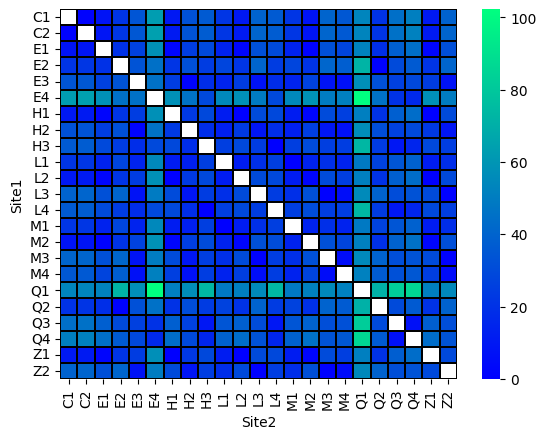

In [39]:
dm_pvt = dm.pivot(index='Site1', columns='Site2', values='dkm')
sns.heatmap(dm_pvt, cmap='winter', mask=np.eye(23), linewidth=0.01, linecolor='black')
# sns.heatmap(dm_pvt, cmap='Spectral')

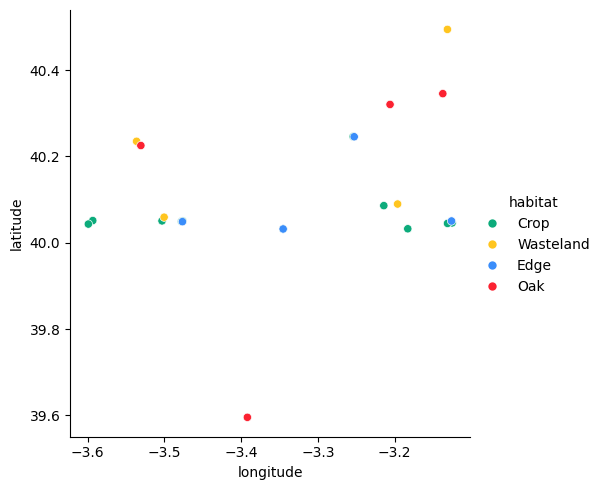

In [40]:
sns.relplot(geography, x='longitude',  y='latitude', hue='habitat', palette=habitat_palette)

In [41]:
geography.query('site == "Q1"')

,site,habitat,latitude,longitude,town
19,Q1,Oak,39.59552,-3.39183,Aranjuez


In [42]:
from skbio.stats.distance import mantel

In [43]:
mantel(
    counts_byspecies_bc_dm.to_data_frame().values, dm_pvt.values
)

(-0.03341002556642056, 0.681, 23)

In [44]:
mantel(
    counts_byspecies_jc_dm.to_data_frame().values, dm_pvt.values
)

(-0.028417977510021154, 0.718, 23)

In [45]:
mantel(
    counts_bygtdbrep_uuf_dm.to_data_frame().values, dm_pvt.values
)

(-0.13033256064568174, 0.185, 23)

In [46]:
mantel(
    counts_bygtdbrep_wuf_dm.to_data_frame().values, dm_pvt.values
)

(-0.1700385456244164, 0.112, 23)

### Host biodiversity

In [47]:
res = data.query(
"""
PREFIX mvrtaxon: <http://localhost:8000/taxon/>
PREFIX mvrlib: <http://localhost:8000/library/>
PREFIX mvront: <http://localhost:8000/ont/>
PREFIX mvrcol: <http://localhost:8000/collection/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#> 
PREFIX emi: <https://purl.org/emi#>
PREFIX uniprotrdfs: <http://purl.uniprot.org/core/>
PREFIX fao: <https://w3id.org/fao-ipgr/multi-passport-descriptor.owl#>

SELECT  ?taxid ?scientific_name ?site ?nextracts
WHERE {
    ?lib mvront:Obtained_from ?host .
    ?lib mvront:nextracts ?nextracts .
    ?host uniprotrdfs:Taxon ?taxon .
    ?taxon dwc:taxonID ?taxid .
    ?taxon dwc:scientificName ?scientific_name .
    ?lib mvront:Sampled_from ?s .
    ?s rdfs:label ?site .
    ?s wlo:habitat ?habitat .
}

"""
)
hosts = pd.DataFrame(res, columns=list(map(str, res.vars)))
hosts['taxid'] = hosts['taxid'].astype(int)
hosts['scientific_name'] = hosts['scientific_name'].apply(lambda x: str(x))
hosts['site'] = hosts['site'].apply(lambda x: str(x))
hosts['nextracts'] = hosts['nextracts'].apply(lambda x: int(x))
hosts

,taxid,scientific_name,site,nextracts
0,3076757,Amaranthus sp,M1,8
1,4123,Convolvulus arvensis,M1,11
2,3656,Cucumis melo,M1,13
3,3656,Cucumis melo,M1,13
4,76433,Cyperus longus,M1,7
...,...,...,...,...
304,301481,Erodium cicutarium,C2,1
305,1464625,Fumaria parviflora,H1,8
306,71354,Hirschfeldia incana,H1,8
307,4513,Hordeum vulgare,H1,8


In [48]:
hosts = hosts.groupby(['site', 'scientific_name'], as_index=False)['nextracts'].sum()
hosts

,site,scientific_name,nextracts
0,C1,Brassica oleracea,25
1,C1,Diplotaxis erucoides,3
2,C1,Picris echioides,1
3,C1,Sisymbrium runcinatum,4
4,C2,Brassica oleracea,20
...,...,...,...
249,Z1,Xanthium strumarium,18
250,Z1,Zea mays,11
251,Z2,Convolvulus arvensis,4
252,Z2,Picris echioides,1


In [49]:
hosts_pvt = hosts.pivot(index=['site'], columns=['scientific_name'], values='nextracts').fillna(0)
hosts_data = hosts_pvt.values
hosts_index = hosts_pvt.index.to_frame()['site'].values

In [50]:
host_bc_dm = beta_diversity('braycurtis', hosts_data, hosts_index)
host_jc_dm = beta_diversity('jaccard', hosts_data, hosts_index)


<Axes: >

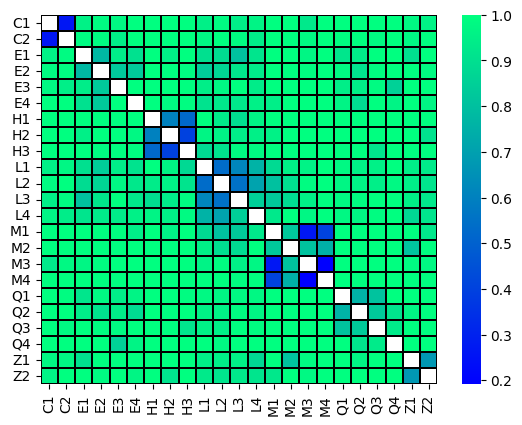

In [51]:
# dm_pvt = dm.pivot(index='Site1', columns='Site2', values='dkm')
sns.heatmap(host_bc_dm.to_data_frame(), cmap='winter', mask=np.eye(23), linewidth=0.01, linecolor='black')
# sns.heatmap(dm_pvt, cmap='Spectral')

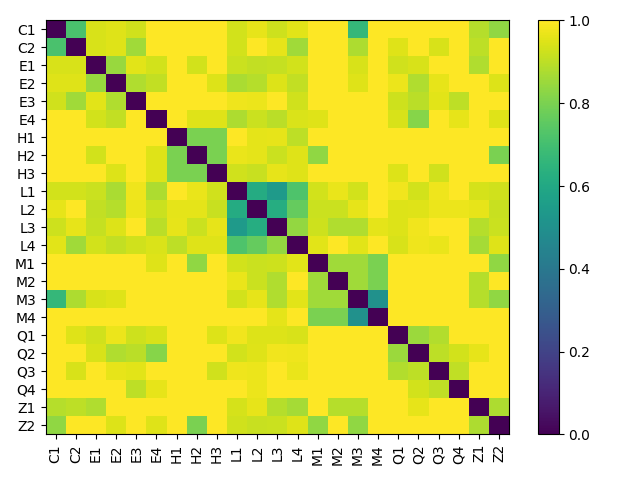

In [52]:
host_jc_dm

In [53]:
mantel(
    counts_byspecies_bc_dm.to_data_frame().values, host_bc_dm.to_data_frame().values
)

(0.45371046261576453, 0.001, 23)

In [54]:
mantel(
    counts_byspecies_jc_dm.to_data_frame().values, host_jc_dm.to_data_frame().values
)

(0.45427356238389466, 0.001, 23)

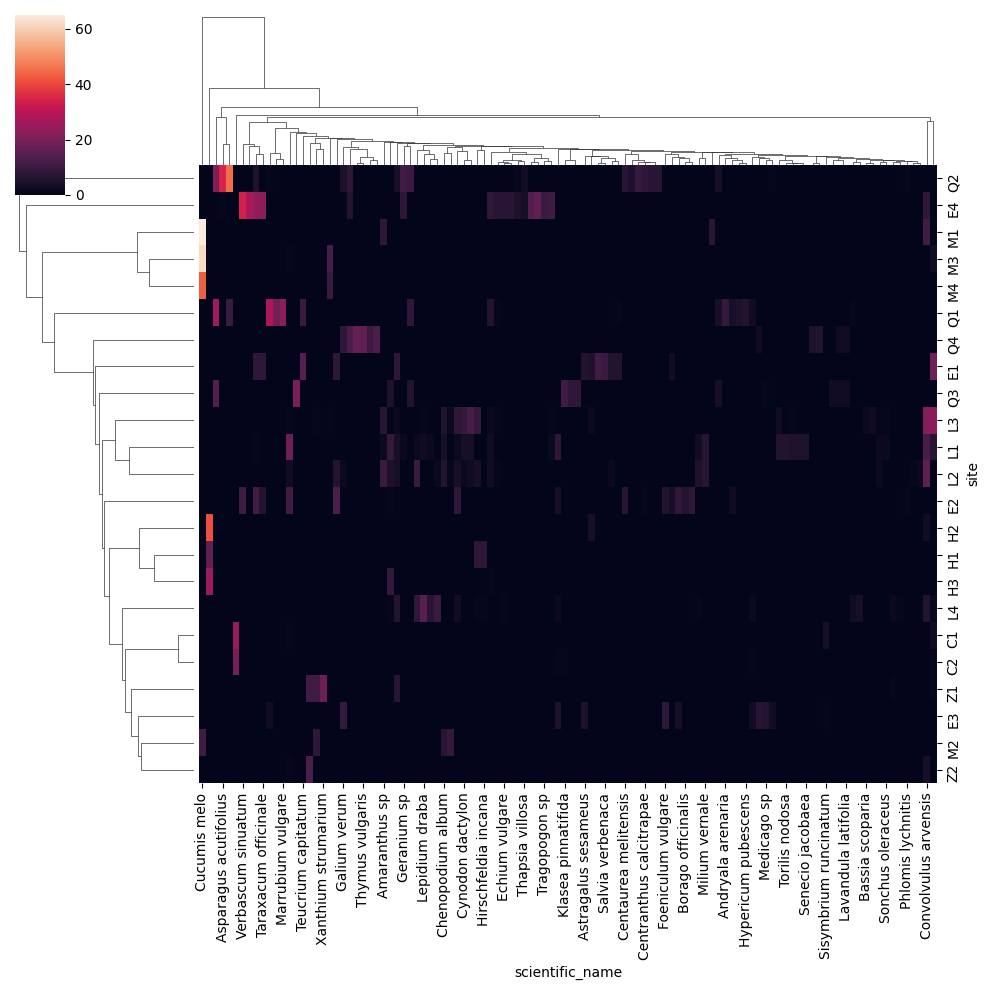

In [55]:
sns.clustermap(hosts_pvt)